In [1]:
!nvidia-smi

Fri Sep 25 16:26:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  GRID V100DX-32C                On  |   00000000:06:00.0 Off |                    0 |
| N/A   N/A    P0            N/A  /  N/A  |     400MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os, sys

nb_path = './'
sys.path.insert(0,nb_path)

In [3]:
# Install packages
!pip install --no-cache-dir shtns
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [5]:
!pip install pyshtools

Defaulting to user installation because normal site-packages is not writeable


In [6]:
!pip install sympy

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import csv
import time
from datetime import datetime
import numpy as np
import pandas as pd
import scipy
from scipy.optimize._numdiff import approx_derivative
import matplotlib.pyplot as plt

import torch
import shtns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

[SHTns 3.7.5] built Jun 13 2026, 12:02:04, id: avx512,ishioka


In [8]:
from math import sqrt, factorial, pi, log
import cmath
from sympy.physics.wigner import wigner_3j
from pyshtools.legendre import PlmIndex, PlmSchmidt_d1

/storage/fi_gt_foldmag_26/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Main utility functions

### Galerkin basis functions and derivatives

In [139]:
# ============================================================
# Jacobi polynomials (vectorized, no tensor recreation)
# ============================================================
def jacobi_recurrence_for_GPU(power, alpha, beta, x):
    if power < 0:
        return torch.zeros_like(x)

    J0 = torch.ones_like(x)
    if power == 0:
        return J0

    J1 = 0.5 * (alpha + beta + 2) * x + 0.5 * (alpha - beta)
    if power == 1:
        return J1

    J_prev = J0
    J_curr = J1

    for n in range(2, power + 1):
        an = (2*(n-1)+alpha+beta+1)*(2*(n-1)+alpha+beta+2) / (2*n*(n+alpha+beta))
        bn = (beta**2 - alpha**2)*(2*(n-1)+alpha+beta+1) / (2*n*(n+alpha+beta)*(2*(n-1)+alpha+beta))
        cn = (n+1+alpha)*(n+1+beta)*(2*(n+1)+alpha+beta+2) / ((n+2)*(n+alpha+beta+2)*(2*(n+1)+alpha+beta))

        J_next = (an * x - bn) * J_curr - cn * J_prev
        J_prev = J_curr
        J_curr = J_next

    return J_curr


# ============================================================
# Psi computation (vectorized)
# ============================================================
def compute_all_Psi_SL(r, sh_two_index, band_nr, min_pol_degr):
    
    r = r.to(device)
    z = 2 * r**2 - 1

    alpha = 0.5
    beta = degree + 0.5


    #######
    Psi = -r**(degree+1)*(-6*alpha-4*degree*alpha+4*degree*alpha*r**2+2*alpha*r**2-24*degree+9*r**2+20*degree*r**2+4*degree**2*r**2-4*degree**2-27) 
 

    Psi_vals = []

    for k in range(min_pol_degr, band_nr):
        if k == 1:
            Psi = -r**(degree+1)*(-6*alpha-4*degree*alpha+4*degree*alpha*r**2+2*alpha*r**2-24*degree+9*r**2+20*degree*r**2+4*degree**2*r**2-4*degree**2-27)
        else:
            c = torch.zeros(3, device=device)
            c[0] = k*(2*degree+5+2*alpha+2*k)*(2*k*alpha**2+2*degree*alpha**2-alpha**2+2*k**2*alpha+5*k*alpha-3*alpha+6*degree*alpha+2*degree*alpha*k-3+4*k**2+2*degree+4*k*degree+2*k)*(2*degree+1+2*alpha+4*k)  
            c[1] = -(1+2*k+2*degree)*(k+2+alpha)*(2*degree+3+2*alpha+4*k)*(2*alpha**3+2*degree*alpha**2+4*k*alpha**2+11*alpha**2+15*alpha+4*k**2*alpha+14*k*alpha+6*degree*alpha+4*degree*alpha*k+8*k**2+8*k*degree+12*k)
            c[2] = (1+2*k+2*degree)*(k+2+alpha)*(alpha**2+2*k*alpha**2+2*degree*alpha**2+4*alpha+8*degree*alpha+2*k**2*alpha+2*degree*alpha*k+9*k*alpha+6*degree+4*k*degree+4*k**2+3+10*k)*(2*degree+5+2*alpha+4*k)
            jacobi_vec = torch.stack([
                jacobi_recurrence_for_GPU(k, alpha, beta, z),
                jacobi_recurrence_for_GPU(k-1, alpha, beta, z),
                jacobi_recurrence_for_GPU(k-2, alpha, beta, z),
            ])

            Psi = r**(degree+1)*torch.matmul(c, jacobi_vec) #

        #TODO: replace .append in the below line w. torch.cat
        Psi_vals.append(Psi)

    return torch.stack(Psi_vals)  # shape: [band_nr-1, N]

# ============================================================
# Produce derivatives of the basis functions
# ============================================================
# def d_psi_d_r(r, n, k, mu):
#     '''
#     Returns the radial derivative of the galerkin polynomial repr. Psi(r)
#     :param r: observation radius
#     :param n: SH degree of the representation
#     :param k: polynomial degree of the representation
#     :param mu: degree-based multiplier
#     :return: d(Psi(r))/dr
#     '''
#     r = r.to(device)
#     alpha = 2
#     beta = n + 1 / 2
#     z = 2 * r**2 - 1
    
#     d_psi_dr_vec = []
#     for k in range(1, band_nr):
#         if k == 1:
#             d_psi_dr = n * r ** (n-1) * (-mu * n - 2 * mu - 1 + r ** 2 * mu * n + r ** 2) + \
#                      r ** n * (-mu * n - 2 * mu - 1 + 2 * r * mu * n + 2 * r)
#         elif k == 2:
#             d_psi_dr = n * r ** (n-1) * (6 * mu * n ** 2 + 27 * mu * n + 27 * mu + 2 * n + 3 - 12 * r ** 2 * n ** 2 * mu - 4 * r ** 2 * n - 58 * r ** 2 * mu * n - 10 * r ** 2 - 70 * r ** 2 * mu + 6 * r ** 4 * n ** 2 * mu + 2 * r ** 4 * n + 31 * r ** 4 * mu * n + 35 * r ** 4 * mu + 7 * r ** 4) + \
#                     r ** n * (6 * mu * n ** 2 + 27 * mu * n + 27 * mu + 2 * n + 3 - 12 * 2 * r * n ** 2 * mu - 4 * 2 * r * n - 58 * 2 * r * mu * n - 10 * 2 * r - 70 * 2 * r * mu + 6 * 4 * r**3 * n ** 2 * mu + 2 * 4 * r ** 3 * n + 31 * 4 * r ** 3 * mu * n + 35 * 4 * r ** 3 * mu + 7 * 4 * r ** 3)

#         c = torch.zeros(4, device=device)
#         c[0] = (2 * n - 3 + 4 * k) * (2 * n + 5 + 2 * k) * (2 * n - 1 + 4 * k) * (
#                     2 * k * mu * n - mu * n + 1 + 2 * k ** 2 * mu - mu - k * mu) * (2 * n + 3 + 2 * k)
#         c[1] = -(2 * n - 3 + 4 * k) * (2 * n + 3 + 2 * k) * (2 * n + 3 + 4 * k) * (2 * n + 1 + 2 * k) * (
#                     -mu * n + 6 * k * mu * n + 3 + k * mu + 6 * k ** 2 * mu + 2 * mu)
#         c[2] = (2 * n - 1 + 4 * k) * (2 * n + 5 + 4 * k) * (2 * n + 1 + 2 * k) * (-1 + 2 * n + 2 * k) * (
#                     6 * k * mu * n + mu * n + 5 * k * mu + 3 + 3 * mu + 6 * k ** 2 * mu)
#         c[3] = -(2 * n - 3 + 2 * k) * (2 * n + 5 + 4 * k) * (2 * n + 3 + 4 * k) * (-1 + 2 * n + 2 * k) * (
#                     2 * k * mu * n + mu * n + 3 * k * mu + 2 * k ** 2 * mu + 1)

#         jacobi_vec = np.zeros([4,1])
#         jacobi_vec = torch.stack([
#                     2 * r * (k + alpha + beta + 1) * jacobi_recurrence_for_GPU(k, alpha, beta, z),
#                     2 * r * (k-1 + alpha + beta + 1) * jacobi_recurrence_for_GPU(k-1, alpha+1, beta+1, z),
#                     2 * r * (k-2 + alpha + beta + 1) * jacobi_recurrence_for_GPU(k-2, alpha+1, beta+1, z),
#                     2 * r * (k-3 + alpha + beta + 1) * jacobi_recurrence_for_GPU(k-3, alpha+1, beta+1, z)
#                 ])
    
#         d_psi_dr = r**n*torch.matmul(c, jacobi_vec)
#         #TODO: replace .append in the below line w. torch.cat
#         d_psi_dr_vec.append(d_psi_dr)
#     return torch.stack(d_psi_dr_vec)

In [100]:
def create_vector_of_galerkin_polynomials_SL(min_pol_degr, gamma_two_index, normalization_mx, band_nr, r, el):
    """
    Constructing the Galerkin-base at each observation radius containing basis functions of each polynomial degree used
     for inverting the coefficients of the Galerkin-representation of the induced field
    :param min_pol_degr: degree-based multiplier
    :param gamma_two_index: SH two-index gamma of the induced field
    :param normalization_mx: array A containing the normalization constants
    :param band_nr: maximum polynomial degree used for the representation
    :param r: radial observation point
    :param el: array containing all SH degrees
    :return: [A^1_{\gamma}Psi^1_{\gamma}(r), A^2_{\gamma}Psi^2_{\gamma}(r), ..., A^K_{\gamma}Psi^K_{\gamma}(r)]
    """
    psi_val = compute_all_Psi_SL(r, el[gamma_two_index], band_nr, min_pol_degr)
    psi_vec = torch.mul(torch.squeeze(psi_val), torch.squeeze(normalization_mx[:,gamma_two_index].T))
    return psi_vec


In [140]:
# =======================================================================
# Normalization coefficients as integrals of unnormalised basis functions
# =======================================================================
def normalization_coeffs_gram_schmidt_SL(sh_two_index, r0, r1, resolution, band_nr, el, min_pol_degr):
    alpha = 0.5

    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)

    Psi_vals = compute_all_Psi_SL(r, el[sh_two_index], band_nr, min_pol_degr)

    # normalization
    Psi_abs = torch.abs(Psi_vals)

    weight = (1-r**2)**alpha

    # Compute all integrals at once
    B_norm_gs = torch.einsum('ir,jr,r->ij', Psi_abs, Psi_abs, weight) * dr

    return B_norm_gs
# ===================================================================================================
# NEW VERSION OF NORMALIZATION CONSTANTS <- ENSURING THE ORTHONORMAL CONDITION FOR THE GALERKING BASE
# [GRAM-SCHMIDT PROCEDURE]
# ===================================================================================================
def derive_normalization_constant_orthonormal(band_nr, min_pol_degr, max_sh_two_index, B_norm_gs):
    gram_schmidt_norm_mx = torch.ones([band_nr-min_pol_degr, max_sh_two_index], device=device)

    for sh_two_index in range(1, max_sh_two_index):
        gram_schmidt_norm_mx[:, sh_two_index] = 1/torch.sqrt(torch.diag(B_norm_gs[:,:,sh_two_index]))
    return gram_schmidt_norm_mx

### SH analysis

In [141]:
# Schmidt-normalized Legendre polynomials
def P(k, l, theta):
    P, dthet_P = PlmSchmidt_d1(k, torch.cos(theta), [1, 0])
    return P[PlmIndex(k,l)], dthet_P[PlmIndex(k,l)]

# Derivatives of Legendre polynomials
#---------------------------------------------------------------------
def derivative_in_theta(k, l, theta):
    return -torch.sin(theta)*P(k,l,theta)[1]

def Y_derivative_in_theta(k, l, theta, phi):
    dP = derivative_in_theta(k, l, theta)
    return (-torch.sin(theta))*(-1)**l*sqrt(((2*k+1)*factorial(k-l))/(factorial(k+l)))*dP*torch.exp(1j*torch.Tensor([1.0]).to(device)*l*phi)

In [142]:
#-------------------------- COMPUTE THE TOROIDAL SH COEFFICIENTS OF A PRESCRIBED AZIMUTHAL FLOW --------------------------------------
def compute_toroidal_flow_coefficients_vectorized(r, Omega, R_oc):
    return Omega * r * R_oc

In [143]:
#-------------------------- COMPUTE THE SH COEFFICIENTS FROM GIVEN SOURCE MF DATA --------------------------------------
def define_3d_grid_for_vector_SH_transform(sh):
    x = sh.spat_array()  # a spatial array, same as numpy.zeros(sh.spat_shape)
    y = x.copy()
    y[:, :] = 0
    z = x.copy()
    z[:, :] = 0
    return x, y, z


def compute_poloidal_source_coefficients(Br_test, x, y, z, sh, r_samples, r_ind, R_oc):
    """
    Performs the spherical harmonic analysis on a map of source field values using an instance of the shtns package (sh)
    with three arguments, sh.alanys() performs a 3D vector transform (spherical coordinates)
    :param Br_test: stack of geographic maps (radial slices) of source field values
    :param x: starting grid
    :param y:
    :param z:
    :param sh: an instance of the shtns package
    :param r_samples: radial sampling points for geomagnetic map slices
    :param r_ind: index of the given geocentric radius of a slice
    :return: S0_r source coefficients; el array of size sh.nlm giving the SH degree l for any SH coefficient,
    l2 array l(l+1) that is useful for computing laplacian
    """
    # TODO: CHECK FOR POSSIBLE APPLICATION OF GPU VERSION HERE! - shtns also has a GPU implementation
    x[:, :] = torch.squeeze(Br_test[:, :, r_ind]).cpu().numpy()
    qlm, slm, tlm = sh.analys(x, y,
                              z)
    el = sh.l 
    em = sh.m
    l2 = el * (el + 1)
    r_dimensional = r_samples[r_ind]*R_oc
    qlm = torch.Tensor(qlm).to(device)
    l2 = torch.Tensor(l2).to(device)
    S0_r = (qlm * r_dimensional) / (l2 + 1)
    return S0_r, el, em, l2


In [144]:
# -------------------------ELSASSER DYNAMO INTEGRAL AS FEATURED IN [5] --------------------------------------------------
def elsasser(n,m,k,l,i,j):
    """
    Evaluates the Elsasser dynamo integral for each corresponding SH degree and order listed below
    :param n: flow order n_gamma
    :param m: flow degree m_gamma
    :param k: source mf order k_beta
    :param l: source mf degree l_beta
    :param i: induced mf order i_gamma
    :param j: induced mf degree j_gamma
    :return: elsasser_nm value of the Elsasser dynamo integral
    """
    Lambda_b_g = cmath.sqrt((2 * n + 1)*(2 * k + 1)*(2 * i + 1))
    Delta_b_g = cmath.sqrt((n + k + i + 2)*(n + k + i + 4) / (4 * (n + k + i + 3))) * cmath.sqrt((n + k - i + 1)*(n + i - k + 1)*(i + k - n + 1))
    elsasser_nm = (-1)**np.float32(j)*(-4j*pi*Lambda_b_g*Delta_b_g*wigner_3j(n+1, k+1, i + 1, 0, 0, 0)*wigner_3j(n, k, i, m, l, j))
    return elsasser_nm

# GLOBAL DEFINITIONS

## Global definitions of basic quantities

In [246]:
# ============================================================
# PHYSICAL QUANTITIES
# ============================================================

# Outer core radius
global R_oc
R_oc = 3.48e6

# Permeability of empty space
global mu_0 
mu_0 = 4 * np.pi * 1e-7

# Core conductivity
sigma = 1e6 # older estimate is 5e5 [S/m]
global eta 
eta = 1 / (mu_0 * sigma)

# Angular velocity of the rotating flow
global Omega 
# Omega = 1.2e-10  # FOR AVG OUTER CORE VELOCITIES: v_oc(~10[km/yr])/r_oc(~2500[km])[1/s]
Omega = 5*1.2e-10  # FOR MAX POTENTIAL OUTER CORE VELOCITIES: v_oc(~50[km/yr])/r_oc(~2500[km])[1/s]

# Normalized spherical domain extension
global r0 
r0 = 0.0
global r1 
r1 = 1.0
# Number of radial sample (observation) points
global nr_r_samples 
nr_r_samples = 25
# Sample radii
global r_samples 
r_samples = torch.linspace(0.01, 1, nr_r_samples, device=device)

# ============================================================
# SPHERICAL HARMONIC DESCRIPTION
# ============================================================
# Geographic resolution (latitude and longitude)
lat_max = 90
long_max = 180

# Spherical harmonic resolution (degree and order)
# lmax = 5
# mmax = 5
lmax = 3
mmax = 3

# Spherical harmonic transformations
global sh 
sh = shtns.sht(lmax, mmax)
nlat, nphi = sh.set_grid(lat_max, long_max)

global el 
el = sh.l
global em 
em = sh.m
global l2 
l2 = el * (el + 1)

# Maximum primary source mf two-indexes
global beta_max 
#beta_max = 21
beta_max = len(el)

# First index of the iteration of SH indices
global gamma_first_index
gamma_first_index = 1
# Maximum induced mf two-indexes
global gamma_max
gamma_max = len(em)

# Alpha indices - for the toroidal flow coefficient - FIXED
global n 
n = 1
global m 
m = 0

# ============================================================
# GALERKIN REPRESENTATION
# ============================================================
# Maximum degree of basis functions
global band_nr 
band_nr = 14
# Minimum degree of basis functions
global min_pol_degr
min_pol_degr = band_nr - gamma_max + 1
# Resolution of numerical integrations
global resolution 
resolution = 100

## Globally utilized preallocated arrays

### Gram-Schmidt normalization of the Galerkin base

In [146]:
B_norm_gs_local = torch.zeros([globals()['band_nr']-globals()['min_pol_degr'], globals()['band_nr']-globals()['min_pol_degr'], globals()['gamma_max']]).to(device)

for gamma_two_index in range(1,globals()['gamma_max']):
    B_norm_gs_local[:,:,gamma_two_index] = normalization_coeffs_gram_schmidt_SL(gamma_two_index, globals()['r0'], globals()['r1'], globals()['resolution'], globals()['band_nr'], globals()['el'], globals()['min_pol_degr'])

global B_norm_gs
B_norm_gs = B_norm_gs_local
del B_norm_gs_local

In [147]:
# ============================================================
# NORMALIZATION
# ============================================================
global normalization_mx 
normalization_mx = derive_normalization_constant_orthonormal(globals()['band_nr'], globals()['min_pol_degr'], globals()['gamma_max'], globals()['B_norm_gs']) 

## Loading primary source field magnetic induction data (radial component)

In [148]:
global Br_test
Br_test = torch.Tensor(np.array(scipy.io.loadmat('B_r_test.mat')['B_r'])).to(device)

# Computing values of the matrix $\mathbf{Psi}_{\gamma}^k(r)$ containing the Galerkin base functions

In [149]:
#TODO: CHECK WHETHER THE SAME RESULT CAN BE OBTAINED FASTER USING THE FULL VECTOR "r_samples" INSTEAD OF single values "r" in the computations
psi_tmp_local = torch.zeros([25, globals()['band_nr']-globals()['min_pol_degr'], globals()['gamma_max']]).to(device)
r_ind = 0
for r in r_samples:
    for gamma_two_index in range(1, globals()['gamma_max']):
        mu = 1 / l2[gamma_two_index]
        psi_tmp_local[r_ind, :, gamma_two_index] = create_vector_of_galerkin_polynomials_SL(globals()['min_pol_degr'], gamma_two_index, globals()['normalization_mx'], globals()['band_nr'], r, globals()['el'])
    r_ind += 1
global PSI_MATRIX
PSI_MATRIX = psi_tmp_local
del psi_tmp_local

# Computing base function derivatives $\frac{d(\Psi_{\gamma}^k(r))}{dr}$ for the boundary condition:
# $\mu\frac{d(S_{\gamma}(r))}{dr}(r=1) + S_{\gamma}(r=1) = 0$

In [150]:
psi_prime_local = torch.zeros([25, globals()['band_nr']-globals()['min_pol_degr'], globals()['gamma_max']]).to(device)
for gamma_two_index in range(1, globals()['gamma_max']):
    for k in range(globals()['band_nr']-globals()['min_pol_degr']):
        psi_prime_local[:,k,gamma_two_index] = torch.gradient(globals()['PSI_MATRIX'][:,k, gamma_two_index])[0]
global PSI_PRIME_MX
PSI_PRIME_MX = psi_prime_local
del psi_prime_local

# Examining the properties of the Elsasser dynamo integral

In [151]:
Elsasser_tmp = torch.zeros([globals()['gamma_max']+1,globals()['beta_max']+1], dtype=torch.complex64).to(device)
for gamma_two_index in range(1, globals()['gamma_max']):
    i = globals()['el'][gamma_two_index]
    j = globals()['em'][gamma_two_index]
    for beta_two_index in list(range(1, globals()['beta_max'])):
        k = globals()['el'][beta_two_index]
        l = globals()['em'][beta_two_index]
        Elsasser_tmp[gamma_two_index,beta_two_index] = torch.tensor([complex(elsasser(globals()['n'], globals()['m'], k, l, i, -j))], dtype=torch.complex64).to(device)

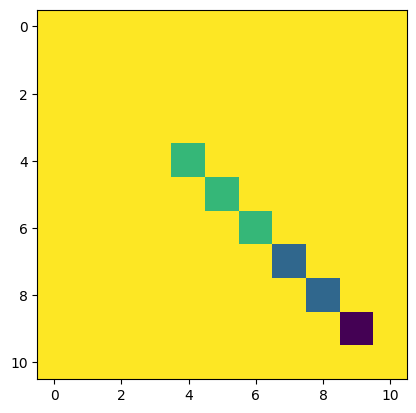

In [152]:
plt.imshow(torch.imag(Elsasser_tmp).cpu().numpy())

## Storing results of the Elsasser dynamo integral $E_{1,\gamma,\beta}^*$ for every SH degree and order 

In [153]:
Elsasser_tmp_for_global = torch.zeros([globals()['lmax']+1,globals()['mmax']+1,globals()['lmax']+1,globals()['mmax']+1], dtype=torch.complex64).to(device)
for gamma_two_index in range(1, globals()['gamma_max']):
    i = globals()['el'][gamma_two_index]
    j = globals()['em'][gamma_two_index]
    for beta_two_index in list(range(1, globals()['beta_max'])):
        k = globals()['el'][beta_two_index]
        l = globals()['em'][beta_two_index]
        Elsasser_tmp_for_global[i,j,k,l] = torch.tensor([complex(elsasser(globals()['n'], globals()['m'], k, l, i, -j))], dtype=torch.complex64).to(device)
global Elsasser_global
Elsasser_global = Elsasser_tmp_for_global
del Elsasser_tmp_for_global

# VALIDATIONS

# Check whether the basis functions form the orthonormal base $\int_0^1\Psi_i(r)\Psi_j(r)(1-r^2)^{\alpha}dr = \delta_{ij}$

In [162]:
# ============================================================
# Orthonormal base validation
# ============================================================
def validate_orthogonality(sh_two_index, r0, r1, resolution, band_nr, normalization_mx, el, min_pol_degr):
    alpha = 0.5
    
    degree = el[sh_two_index]

    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)

    Psi_vals = compute_all_Psi_SL(r, sh_two_index, band_nr, min_pol_degr)

    # normalization
    norm = normalization_mx[:, sh_two_index].to(device)
    Psi_vals = Psi_vals * norm[:, None]

    weight = (1-r**2)**alpha

    # Compute all integrals at once
    Base_product = torch.einsum('ir,jr,r->ij', Psi_vals, Psi_vals, weight) * dr

    return Base_product

In [155]:
Base_product = torch.zeros([globals()['band_nr']-globals()['min_pol_degr'], globals()['band_nr']-globals()['min_pol_degr'], globals()['gamma_max']]).to(device)
gamma_two_index = 1
Base_product = validate_orthogonality(
gamma_two_index,
globals()['r0'],
globals()['r1'],
globals()['resolution'],
globals()['band_nr'],
globals()['normalization_mx'],
globals()['el'],
globals()['min_pol_degr']
)

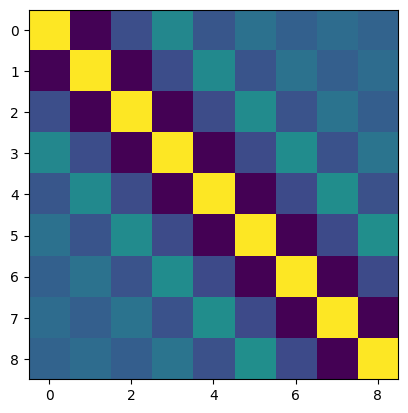

In [156]:
plt.imshow(Base_product.cpu().numpy())

In [158]:
import gc
gc.collect()

30

### Calculating source primary field and prescribed azimuthal flow SH coefficients

In [159]:
x, y, z = define_3d_grid_for_vector_SH_transform(globals()['sh'])
S0_r = torch.zeros([globals()['nr_r_samples'],globals()['gamma_max']]).to(device)
for r_ind in range(globals()['nr_r_samples']):
    S0_r[r_ind], el, em, l2 = compute_poloidal_source_coefficients(globals()['Br_test'], x, y, z, globals()['sh'], globals()['r_samples'], r_ind, globals()['R_oc']) #torch.tensor(1.0).to(device)

/tmp/ipykernel_2998298/929208234.py:33: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:308.)
  qlm = torch.Tensor(qlm).to(device)


In [160]:
t_10 = compute_toroidal_flow_coefficients_vectorized(globals()['r_samples'], globals()['Omega'], torch.tensor(1.0).to(device)) #globals()['R_oc']
t_10 = torch.tensor(t_10, dtype=torch.complex64).to(device)

/tmp/ipykernel_2998298/1565104412.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_10 = torch.tensor(t_10, dtype=torch.complex64).to(device)


# SOLVING THE STURM-LIOUVILLE REPRESENTATION OF THE BG EQUATIONS FOR THE INDUCED POLOIDAL FIELDS

In [165]:
def K_SL(r, eta):
    K_sl = eta*r**2
    return K_sl

def c_SL(r):
    return r

def rho_SL(r):
    return r

def alpha_SL(tau, r, sh_two_index, eta, el, elsasser):
    degree = el[sh_two_index]
    e_gamma = elsasser[sh_two_index, sh_two_index]
    rho_sl = r**2*tau*e_gamma/(4*torch.pi) - eta*degree*(degree+1)

In [186]:
def q_SL(S0_r, psi_r, sh_two_index, c_SL, rho_SL):
    S0_gamma = torch.squeeze(S0_r[:,sh_two_index])
    resolution = S0_r.shape[0]
    
    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)
    
    psi_gamma = torch.squeeze(psi_r[:, :, sh_two_index])

    weight = c_sl*rho_sl

    # Compute all integrals at once
    q_sl_num = torch.einsum('...r,...rj,...r->...j', S0_gamma, psi_gamma, weight) * dr
    q_sl_denom = torch.einsum('rj,rj,...r->...j', psi_gamma, psi_gamma, weight) * dr
    q_sl = q_sl_num/q_sl_denom
    return q_sl

In [189]:
r = torch.linspace(r0, r1, 25, device=device)
c_sl = c_SL(r)
rho_sl = rho_SL(r)

tensor([-0.0009,  0.0005,  0.0005,  0.0008,  0.0009,  0.0010,  0.0011,  0.0010,
         0.0008], device='cuda:0')

In [191]:
k_sl = K_SL(r, globals()['eta']) 

In [206]:
def lambda_SL(sh_two_index, k_sl, c_sl, rho_sl,psi_r, psi_prime_r):

    eval_deriv = -(k_sl[24]-k_sl[0]) * (psi_r[24,:,sh_two_index]-psi_r[0,:,sh_two_index]) * (psi_prime_r[24,:,sh_two_index]-psi_prime_r[0,:,sh_two_index])
      
    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)
    
    psi_gamma = torch.squeeze(psi_r[:, :, sh_two_index])
    psi_prime_gamma = torch.squeeze(psi_prime_r[:, :, sh_two_index])

    weight_k = k_sl
    weight_c_rho = c_sl*rho_sl

    # Compute all integrals at once
    lambda_sl_num = torch.einsum('rj,rj,...r->...j', psi_prime_gamma, psi_prime_gamma, weight_k) * dr
    lambda_sl_denom = torch.einsum('rj,rj,...r->...j', psi_gamma, psi_gamma, weight_c_rho) * dr
    lambda_sl = (eval_deriv + lambda_sl_num)/lambda_sl_denom
    return lambda_sl

In [208]:
lambdas = torch.zeros(globals()['band_nr']-globals()['min_pol_degr'],globals()['gamma_max']).to(device)
qs = torch.zeros(globals()['band_nr']-globals()['min_pol_degr'],globals()['gamma_max']).to(device)
for gamma_two_index in range(1,globals()['gamma_max']):
    qs[:,gamma_two_index] = q_SL(S0_r, globals()['PSI_MATRIX'], gamma_two_index, c_SL, rho_SL)
    lambdas[:,gamma_two_index] = lambda_SL(gamma_two_index, k_sl, c_sl, rho_sl,globals()['PSI_MATRIX'], globals()['PSI_PRIME_MX'])

# Reconstruct the induced mf

In [213]:
time_steps = 10

In [215]:
S_induced = torch.zeros([globals()['nr_r_samples'],globals()['gamma_max'], time_steps]).to(device)

In [236]:
time_step = 1
for gamma_two_index in range(1,globals()['gamma_max']):
    r_ind = 0
    for r in r_samples:
        psi_gamma = torch.squeeze(globals()['PSI_MATRIX'][r_ind,:,gamma_two_index])
        q_gamma = torch.squeeze(qs[:,gamma_two_index])
        lambda_gamma = torch.squeeze(lambdas[:,gamma_two_index])
        ksi_gamma_r = psi_gamma * q_gamma
        time_decay = torch.exp(lambda_gamma*time_step)#.expand(1,)
        S_induced[r_ind,gamma_two_index-1,time_step] = torch.matmul(ksi_gamma_r,time_decay.T)
        r_ind += 1

In [253]:
S_induced_np = torch.squeeze(S_induced[:,:,1]).cpu().numpy()

In [254]:
l2 = el * (el + 1)

In [270]:
#---------------- RECONSTRUCTING SOLUTION MF AT OBSERVATION RADIUS r FROM SOLUTION COEFFICIENTS Sij(r) ---------------------------
#l2_np = l2.cpu().numpy()
r_np = r_samples[24].cpu().numpy()
qij = S_induced_np[24,:]*(l2+1)/r_np


In [271]:
#qij = qij.cpu().numpy()
q_res = sh.spec_array()
q_res = qij
q_res = q_res.astype(dtype=complex)

In [272]:
B_r_reconstr = sh.synth(q_res)

## Map of induced magnetic field data at depth ...

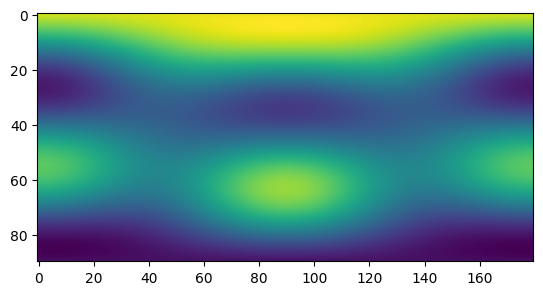

In [273]:
plt.imshow(np.real(B_r_reconstr))

In [269]:
np.max(np.real(B_r_reconstr))

np.float64(1.0373025735453643)

## Map of primary magnetic field data of the sourc at depth ...

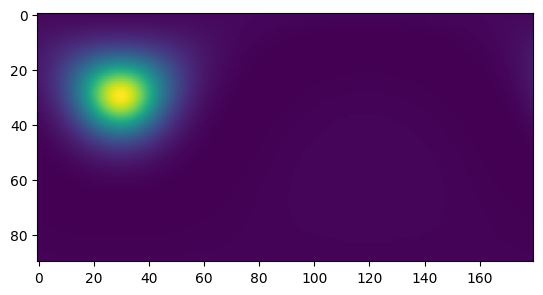

In [336]:
plt.imshow(Br_test[:,:,24].cpu().numpy())

In [260]:
np.max(globals()['Br_test'][:,:,23].cpu().numpy())

np.float32(6.31631e-06)